## Projet traitement du signal

## I. Principe

- On vérifie que sur la durée d’un chirp, la distance 𝑟(𝑡) est à peu près constante :

Or : $v_{max} = 64 m.s^{-1} = 230.4 km.h^{-1}$, $T_{chirp} = \frac{22}{3} \mu s$

Donc :
$$\Delta r_{chirp} = v_{max} \times T_{chirp}$$
$$\Delta r_{chirp} = 64 \times \left(\frac{22}{3} \times 10^{-6}\right)$$
$$\Delta r_{chirp} \approx 4.69 \times 10^{-4} m$$

La variation maximale de $r(t)$ est donc d'environ 0.5 mm << 200m (distance de détection max).

- On Vérifie que c’est également le cas sur la durée de toute la salve de chirp : 

Or : $N_{chirp} = 64$ chirps, de même on a :

$$\Delta r_{salve} = N_{chirp} \times \Delta r_{chirp}$$
$$\Delta r_{salve} \approx 3.00 \times 10^{-2} m$$

La variation reste donc toujours très faible par rapport à l'échelle de porter du radar.

## II. Démodulation et bande de base

### A. Démodulation du signal reçu

Le signal reçu à l'antenne est égal à : $x_R(t) = a(r(t))\cos(\phi_R(t))$

Après amplification par le bloc LNA, le signal devient : $y(t) = k \cdot a(r(t))\cos(\phi_R(t))$

Ce signal est séparé en deux voies et multiplié par $\cos(\phi_T(t))$ et $\sin(\phi_T(t))$ :

- Voie 1 :

Après multiplication par $\cos(\phi_T(t))$ : 
$s_1(t) = k \cdot a(r(t))\cos(\phi_R(t))\cos(\phi_T(t))$

Comme $\cos(a)\cos(b) = \frac{1}{2}[\cos(a-b) + \cos(a+b)]$ :

$s_1(t) = \frac{k}{2} a(r(t)) \left[ \cos(\phi_R(t) - \phi_T(t)) + \cos(\phi_R(t) + \phi_T(t)) \right]$

Or $\cos(\phi_R(t) + \phi_T(t))$ oscille à très haute fréquence (proche de $2\omega_c$), donc le filtre passe-bas idéal (bloc "IF") va totalement éliminer cette composante haute fréquence.

Il reste en sortie du filtre par parité du cos :
$$s_{1,filtre}(t) = \frac{k}{2} \cdot a(r(t))\cos(\phi_T(t) - \phi_R(t))$$

- Voie 2 :

En utilisant l'identité $\sin(a)\cos(b) = \frac{1}{2}[\sin(a-b) + \sin(a+b)]$, on trouve de même : 
$$s_{2,filtre}(t) = \frac{k}{2} \cdot a(r(t))\sin(\phi_T(t) - \phi_R(t))$$

Pour réaliser un tel filtre, il faut conserver la fréquence cible, $f_{cible} = \frac{1}{2\pi}(\phi_T(t) - \phi_R(t))$ et d'éliminer les hautes fréquence (environ $2\omega_c$).

Il faut donc choisir $f_{coupure}$ tel que : $f_{cible} < f_{coupure} << 2f_c$

On a : $\phi_T(t) - \phi_R(t) = 2\omega_c\frac{r(t)}{c} + 2\beta\frac{r(t)}{c}t - 2\beta\left(\frac{r(t)}{c}\right)^2$

Comme $\frac{r(t)}{c} << 1$ : $\phi_T(t) - \phi_R(t) \approx 2\omega_c\frac{r(t)}{c} + 2\beta\frac{r(t)}{c}t$

Donc $f_{cible, max} = \frac{1}{2\pi} \frac{2 \beta r_{max}}{c} \approx 2.72 \cdot 10^{7} Hz$

Comme $f_c = 77 GHz$ : 
$$2.72 \cdot 10^{7} Hz < f_{coupure} << 1.54 \cdot 10^{11} Hz$$




### B. Démodulation en bande de base

Pour obtenir le même résultat, il suffit de multiplier le signal transmis par le complexe conjugué du signal reçu :

$$\tilde{x}_{demod}(t) = \tilde{x}_T(t) \cdot \tilde{x}_R^*(t)$$
$$\tilde{x}_{demod}(t) = \exp(j\phi_T(t) - j\omega_c t) \cdot a(r(t)) \exp(-j\phi_R(t) + j\omega_c t)$$
$$\tilde{x}_{demod}(t) = a(r(t)) \exp(j(\phi_T(t) - \omega_c t - \phi_R(t) + \omega_c t))$$
$$\tilde{x}_{demod}(t) = a(r(t)) \exp(j(\phi_T(t) - \phi_R(t)))$$

Comme $e^{j\theta} = \cos(\theta) + j\sin(\theta)$) :
$$\tilde{x}_{demod}(t) = a(r(t)) \cos(\phi_T(t) - \phi_R(t)) + j \cdot a(r(t)) \sin(\phi_T(t) - \phi_R(t))$$

(lignes latex faites par IA)

Ainsi la partie réelle (resp. imaginaire) correspond à la voie 1 (resp. 2)

Ensuite on travaille en bande de base car sinon les signaux oscillerait avec une fréquence de l'ordre de $\omega_c$, donc d'après le théorème de Shannon-Nyquist l'échantillonage devrait se faire à un fréquence supérieure à $2f_c = 154 GHz$, ce qui est bien trop élevé...

Alors qu'en bande de base, comme on l'a vu précédemment, la fréquence d'oscillation est de l'ordre de la dizaine de MHz, qui est supportable d'un point de vu informatique.

Enfin le DSP ne perd aucune information utile en soustrayant la composante $\omega_c$. En effet, toute l'information importante est encodée dans l'atténuation $a(r(t))$ et le retard $\phi_T(t) - \phi_R(t)$.

## III. Examen des signaux fournis

(8800,)
La fréquence d'échantillonnage est égale à 1e+09 Hz
Erreur moyenne : 3.83e-18


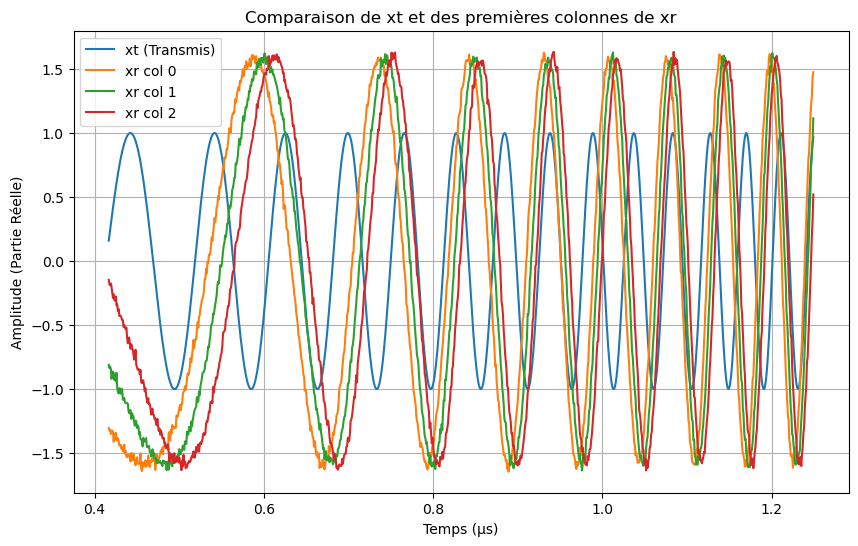

In [12]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

data = sio.loadmat('radar.mat')
xt = data['xt'].flatten()  # car sinon ça bug quand on calcule l'erreur
print(xt.shape)
xr = data['xr']

B = 150e6
T_chirp = 22e-6 / 3
beta = 2 * np.pi * B / T_chirp
N = len(xt) #  = 8800

# freq echantillonnage
Fe = N / T_chirp
print(f"La fréquence d'échantillonnage est égale à {Fe:.0e} Hz")

# on fabrique xt
t = np.arange(N) / Fe
xt_fabrique = np.exp(1j * (beta / 2) * t**2)

# On compare l'erreur absolue moyenne entre notre signal et xt
erreur = np.mean(np.abs(xt - xt_fabrique))
print(f"Erreur moyenne : {erreur:.2e}") 

# Affichage de la partie réelle des signaux (sur les 500 premiers points pour zoomer)
plt.figure(figsize=(10, 6))

plt.plot(t[500:1500] * 1e6, np.real(xt[500:1500]), label='xt (Transmis)')
plt.plot(t[500:1500] * 1e6, np.real(xr[500:1500, 0]) * 1e4, label='xr col 0')
plt.plot(t[500:1500] * 1e6, np.real(xr[500:1500, 1]) * 1e4, label='xr col 1')
plt.plot(t[500:1500] * 1e6, np.real(xr[500:1500, 2]) * 1e4, label='xr col 2')

plt.xlabel('Temps (µs)')
plt.ylabel('Amplitude (Partie Réelle)')
plt.title('Comparaison de xt et des premières colonnes de xr')
plt.legend()
plt.grid(True)
plt.show()

Ensuite, comme on a $r(t) = \frac{c \cdot \Delta t}{2}$

On détermine graphiquement $\Delta t = ?$ [A FAIRE]

D'où, $r(t) = ?$

Enfin, cette estimation ne pourrait pas se faire dans le bloc DSP car comme on l'a vu avant il faudrait donc échantilloner à 154 GHz.